### This notebook demonstrates how to build and evaluate an XGBoost regression model as baseline model following these steps:
 1. Load and preprocess the data
 2. Train the XGBoost model
 3. Perform cross-validation and hyperparameter tuning
 4. Evaluate the model's performance on the test set

### 1. Read the cleaned dataset ###

#### 2. Train an XGBoost model ###

In [12]:
### Import necessary libraries for modeling ###
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from scipy.stats import kendalltau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import PredefinedSplit, cross_validate
from xgboost import XGBRegressor

In [13]:
# Set random seed for reproducibility
torch.manual_seed(101)
np.random.seed(101)
random.seed(101)

In [29]:
TARGET_VARIABLE = "Mole fraction"
XGBOOST_DIR = "./xgboost_final"

In [16]:
X_train = pd.read_csv(".\processed_data\X_train.csv")
X_test = pd.read_csv(".\processed_data\X_test.csv")
X_val = pd.read_csv(".\processed_data\X_val.csv")
y_train = pd.read_csv(".\processed_data\y_train.csv")
y_test = pd.read_csv(".\processed_data\y_test.csv")
y_val = pd.read_csv(".\processed_data\y_val.csv")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
C:\Users\admin\AppData\Local\Temp\ipykernel_38672\3649408530.py:1: SyntaxWarning: invalid escape sequence '\p'
  X_train = pd.read_csv(".\processed_data\X_train.csv")
C:\Users\admin\AppData\Local\Temp\ipykernel_38672\3649408530.py:2: SyntaxWarning: invalid escape sequence '\p'
  X_test = pd.read_csv(".\processed_data\X_test.csv")
C:\Users\admin\AppData\Local\Temp\ipykernel_38672\3649408530.py:3: S

In [17]:
X_train.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True,
)
X_test.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True,
)
X_val.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True,
)

In [18]:
def separate_features(X):
    return (
        X.iloc[:, 0:3],
        X.iloc[:, 3:203],
        X.iloc[:, 203:403],
        X.iloc[:, 403:428],
        X.iloc[:, 428:],
    )


# property_T_P, Component 1 Descriptors, Component 2 Descriptors, Property category, phase

In [19]:
(
    X_train_prop,
    X_train_comp1_desc,
    X_train_comp2_desc,
    X_train_prop_cat,
    X_train_phase,
) = separate_features(X_train)
X_test_prop, X_test_comp1_desc, X_test_comp2_desc, X_test_prop_cat, X_test_phase = (
    separate_features(X_test)
)
X_val_prop, X_val_comp1_desc, X_val_comp2_desc, X_val_prop_cat, X_val_phase = (
    separate_features(X_val)
)

In [20]:
def make_symmetric(comp1, comp2):
    X1 = np.array(comp1)
    X2 = np.array(comp2)
    prod = pd.DataFrame(X1 * X2, columns=[f"prod_{i}" for i in range(X1.shape[1])])
    summ = pd.DataFrame(X1 + X2, columns=[f"sum_{i}" for i in range(X1.shape[1])])
    return pd.concat([prod, summ], axis=1)


X_train_symmetric = make_symmetric(X_train_comp1_desc, X_train_comp2_desc)
X_val_symmetric = make_symmetric(X_val_comp1_desc, X_val_comp2_desc)
X_test_symmetric = make_symmetric(X_test_comp1_desc, X_test_comp2_desc)

# Reconstruct full feature matrix


def reconstruct(prop, symmetric, prop_cat, phase):
    dfs = [prop, symmetric, prop_cat, phase]
    for df in dfs:
        df.reset_index(drop=True, inplace=True)
    return pd.concat(dfs, axis=1)


X_train = reconstruct(X_train_prop, X_train_symmetric, X_train_prop_cat, X_train_phase)
X_val = reconstruct(X_val_prop, X_val_symmetric, X_val_prop_cat, X_val_phase)
X_test = reconstruct(X_test_prop, X_test_symmetric, X_test_prop_cat, X_test_phase)

### 3. Hyperparameter Tuning ###

In [21]:
# -1 = training, 0 = validation
split_index = np.concatenate([np.full(len(X_train), -1), np.zeros(len(X_val))])

X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

ps = PredefinedSplit(test_fold=split_index)

In [22]:
def objective(trial) -> float:
    # define the hyperparameters range to search
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state": 101,
        "n_jobs": 1,
    }

    model = XGBRegressor(**params)

    cv_score = cross_validate(
        model, X_trainval, y_trainval, cv=ps, scoring="r2", n_jobs=-1
    )["test_score"].mean()

    return cv_score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)
print("Best trial:", study.best_trial.number)
print("Best R2:", study.best_value)
print("Best params:", study.best_params)

# Save the best parameters to a JSON file for later use


def save_best_params(study, save_path="./xgboost/xgboost_best_params.json") -> str:
    import json
    import os

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    with open(save_path, "w") as f:
        json.dump(study.best_params, f)

    print(f"Best parameters saved to {save_path}")
    return save_path

[I 2026-04-09 13:30:11,185] A new study created in memory with name: no-name-3ec1d82b-f46e-4a20-abce-db7eef9ff3fc
Best trial: 0. Best value: 0.647292:   2%|▏         | 1/50 [00:12<10:10, 12.47s/it]

[I 2026-04-09 13:30:23,660] Trial 0 finished with value: 0.6472924548151592 and parameters: {'n_estimators': 51, 'learning_rate': 0.10491491765165227, 'max_depth': 10, 'subsample': 0.7828454364398423, 'colsample_bytree': 0.5276461747575056}. Best is trial 0 with value: 0.6472924548151592.


Best trial: 0. Best value: 0.647292:   2%|▏         | 1/50 [00:14<11:39, 14.27s/it]

[W 2026-04-09 13:30:25,418] Trial 1 failed with parameters: {'n_estimators': 59, 'learning_rate': 0.20961908902296889, 'max_depth': 7, 'subsample': 0.7922529476474728, 'colsample_bytree': 0.867789158798002} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\admin\Desktop\CHE1148-VLE-Project\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\admin\AppData\Local\Temp\ipykernel_38672\203553788.py", line 15, in objective
    cv_score = cross_validate(
               ~~~~~~~~~~~~~~^
        model, X_trainval, y_trainval, cv=ps, scoring="r2", n_jobs=-1
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )["test_score"].mean()
    ^
  File "C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "C:\Users\admin\AppData\Local\Progr

KeyboardInterrupt: 

In [23]:
save_best_params(
    study=study, save_path="./xgboost_final/xgboost_best_params_final.json"
)

NameError: name 'save_best_params' is not defined

### 4. Evaluate the model's performance on the test set ###

In [35]:
def evaluate_model(
    model,
    X_test,
    y_test,
    show_plot=False,
    save_file=False,
    save_path=os.path.join(XGBOOST_DIR, "test_results.json"),
    filename="results",
    n_bootstrap=1000,
):
    """Evaluate XGBoost on test set with bootstrap 95% CI (mu +/- 1.96*std)."""
    y_pred = model.predict(X_test)
    y_test = np.array(y_test).flatten()

    # Point estimates
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    tau = kendalltau(y_test, y_pred).correlation

    # Bootstrap on test set
    rng = np.random.default_rng(101)
    mae_scores, mse_scores, r2_scores, tau_scores = [], [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_test), len(y_test))
        mae_scores.append(mean_absolute_error(y_test[idx], y_pred[idx]))
        mse_scores.append(mean_squared_error(y_test[idx], y_pred[idx]))
        r2_scores.append(r2_score(y_test[idx], y_pred[idx]))
        tau_scores.append(kendalltau(y_test[idx], y_pred[idx]).correlation)

    def ci95(scores):
        mu = np.mean(scores)
        std = np.std(scores, ddof=1)
        return mu, std, mu - 1.96 * std, mu + 1.96 * std

    mae_mu, mae_std, mae_lo, mae_hi = ci95(mae_scores)
    mse_mu, mse_std, mse_lo, mse_hi = ci95(mse_scores)
    r2_mu, r2_std, r2_lo, r2_hi = ci95(r2_scores)
    tau_mu, tau_std, tau_lo, tau_hi = ci95(tau_scores)

    print(
        f"MAE         = {mae:.4f}  |  bootstrap mu={mae_mu:.4f}, std={mae_std:.4f}  (95% CI: {mae_lo:.4f} – {mae_hi:.4f})"
    )
    print(
        f"MSE         = {mse:.4f}  |  bootstrap mu={mse_mu:.4f}, std={mse_std:.4f}  (95% CI: {mse_lo:.4f} – {mse_hi:.4f})"
    )
    print(
        f"R²          = {r2:.4f}  |  bootstrap mu={r2_mu:.4f}, std={r2_std:.4f}  (95% CI: {r2_lo:.4f} – {r2_hi:.4f})"
    )
    print(
        f"Kendall’s τ  = {tau:.4f}  |  bootstrap mu={tau_mu:.4f}, std={tau_std:.4f}  (95% CI: {tau_lo:.4f} – {tau_hi:.4f})"
    )

    results = {
        "MAE": {
            "value": mae,
            "bootstrap_mu": mae_mu,
            "bootstrap_std": mae_std,
            "ci95_lo": mae_lo,
            "ci95_hi": mae_hi,
        },
        "MSE": {
            "value": mse,
            "bootstrap_mu": mse_mu,
            "bootstrap_std": mse_std,
            "ci95_lo": mse_lo,
            "ci95_hi": mse_hi,
        },
        "R2": {
            "value": r2,
            "bootstrap_mu": r2_mu,
            "bootstrap_std": r2_std,
            "ci95_lo": r2_lo,
            "ci95_hi": r2_hi,
        },
        "Kendall_tau": {
            "value": tau,
            "bootstrap_mu": tau_mu,
            "bootstrap_std": tau_std,
            "ci95_lo": tau_lo,
            "ci95_hi": tau_hi,
        },
    }

    if save_file:
        os.makedirs(os.path.dirname(os.path.abspath(save_path)), exist_ok=True)
        with open(save_path, "w") as f:
            json.dump(results, f, indent=2)
        print(f"Results saved to {save_path}")

    if show_plot:
        plot_dir = (
            os.path.dirname(os.path.abspath(save_path)) if save_file else XGBOOST_DIR
        )

        # Actual vs Predicted scatter
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(y_test, y_pred, alpha=0.1, s=10)
        lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
        ax.plot(lims, lims, "r--", label="Perfect fit")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title("Actual vs Predicted")
        ax.legend()
        scatter_path = os.path.join(plot_dir, f"{filename}_actual_vs_predicted.png")
        fig.savefig(scatter_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Scatter plot saved to {scatter_path}")

        # Distribution histogram: True vs Predicted
        fig, ax = plt.subplots(figsize=(7, 5))
        bins = np.linspace(
            min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max()), 50
        )
        ax.hist(
            y_test,
            bins=bins,
            alpha=0.6,
            label="True",
            color="steelblue",
            edgecolor="none",
        )
        ax.hist(
            y_pred,
            bins=bins,
            alpha=0.6,
            label="Predicted",
            color="darkorange",
            edgecolor="none",
        )
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
        ax.set_title("Distribution: True vs Predicted")
        ax.legend()
        hist_path = os.path.join(plot_dir, f"{filename}_distribution_histogram.png")
        fig.savefig(hist_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Histogram saved to {hist_path}")

    return results

In [36]:
# Obtain the best model using the best hyperparameters found by Optuna
best_params = pd.read_json(
    "./xgboost_final/xgboost_best_params_final.json", typ="series"
)
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])
best_model = XGBRegressor(
    max_depth=int(best_params["max_depth"]),
    n_estimators=int(best_params["n_estimators"]),
    learning_rate=best_params["learning_rate"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    random_state=101,
    verbosity=0,
)

In [37]:
print(best_params)

n_estimators        179.000000
learning_rate         0.176464
max_depth            10.000000
subsample             0.999434
colsample_bytree      0.995719
dtype: float64


MAE         = 0.0825  |  bootstrap mu=0.0825, std=0.0011  (95% CI: 0.0804 – 0.0846)
MSE         = 0.0190  |  bootstrap mu=0.0190, std=0.0006  (95% CI: 0.0179 – 0.0201)
R²          = 0.8004  |  bootstrap mu=0.8003, std=0.0059  (95% CI: 0.7888 – 0.8118)
Kendall’s τ  = 0.7474  |  bootstrap mu=0.7474, std=0.0038  (95% CI: 0.7399 – 0.7549)
Results saved to ./xgboost_final\test_results.json


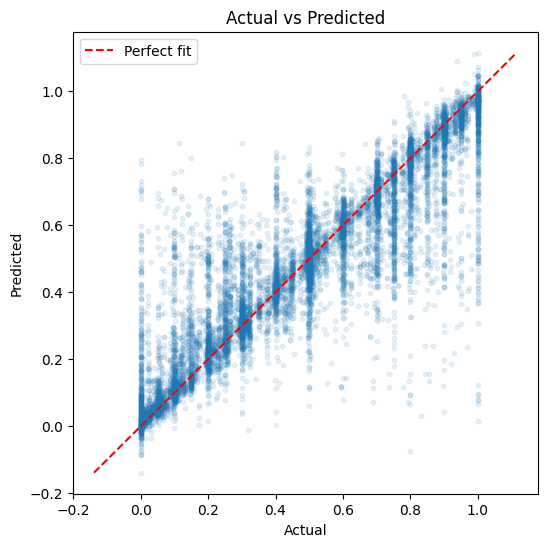

Scatter plot saved to C:\Users\admin\Desktop\CHE1148-VLE-Project\xgboost_final\test_actual_vs_predicted.png


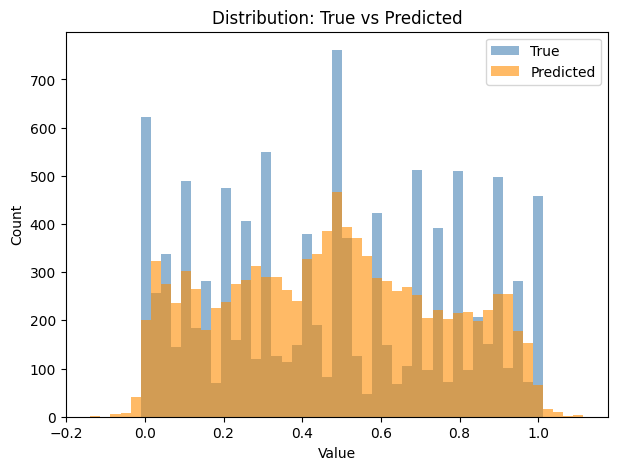

Histogram saved to C:\Users\admin\Desktop\CHE1148-VLE-Project\xgboost_final\test_distribution_histogram.png
MAE         = 0.0831  |  bootstrap mu=0.0831, std=0.0011  (95% CI: 0.0810 – 0.0851)
MSE         = 0.0190  |  bootstrap mu=0.0190, std=0.0005  (95% CI: 0.0180 – 0.0200)
R²          = 0.7997  |  bootstrap mu=0.7996, std=0.0055  (95% CI: 0.7887 – 0.8105)
Kendall’s τ  = 0.7468  |  bootstrap mu=0.7468, std=0.0037  (95% CI: 0.7394 – 0.7541)
Results saved to ./xgboost_final\test_results.json


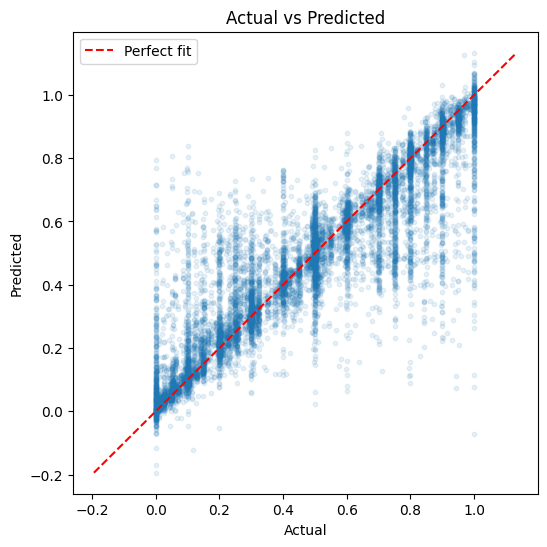

Scatter plot saved to C:\Users\admin\Desktop\CHE1148-VLE-Project\xgboost_final\val_actual_vs_predicted.png


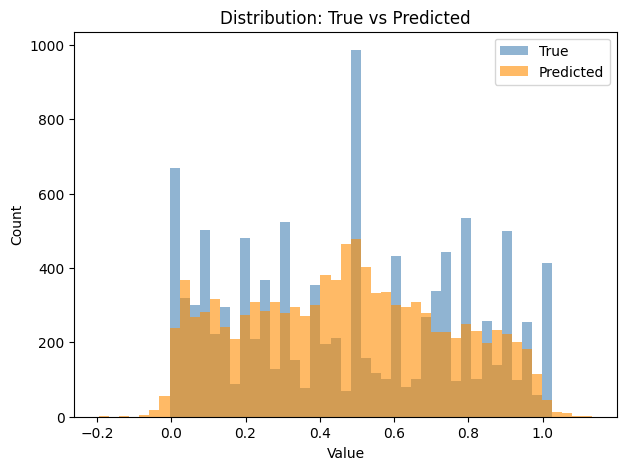

Histogram saved to C:\Users\admin\Desktop\CHE1148-VLE-Project\xgboost_final\val_distribution_histogram.png


{'MAE': {'value': 0.08305644123001962,
  'bootstrap_mu': np.float64(0.08305894366992661),
  'bootstrap_std': np.float64(0.0010520454287487214),
  'ci95_lo': np.float64(0.08099693462957912),
  'ci95_hi': np.float64(0.0851209527102741)},
 'MSE': {'value': 0.018990508443233554,
  'bootstrap_mu': np.float64(0.018988044057889397),
  'bootstrap_std': np.float64(0.000513268717312891),
  'ci95_lo': np.float64(0.017982037371956132),
  'ci95_hi': np.float64(0.019994050743822663)},
 'R2': {'value': 0.7996619071810075,
  'bootstrap_mu': np.float64(0.7996189510522013),
  'bootstrap_std': np.float64(0.005547886417677242),
  'ci95_lo': np.float64(0.7887450936735538),
  'ci95_hi': np.float64(0.8104928084308487)},
 'Kendall_tau': {'value': np.float64(0.7467639487845877),
  'bootstrap_mu': np.float64(0.7467633642684185),
  'bootstrap_std': np.float64(0.003748251616324662),
  'ci95_lo': np.float64(0.7394167911004221),
  'ci95_hi': np.float64(0.7541099374364149)}}

In [38]:
best_model.fit(X_train, y_train)
evaluate_model(
    best_model, X_test, y_test, show_plot=True, save_file=True, filename="test"
)
evaluate_model(best_model, X_val, y_val, show_plot=True, save_file=True, filename="val")